In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt
!pip -q install kneed
from kneed import KneeLocator
import gc, time
from google.colab import drive
import sys
from pathlib import Path
from sklearn.metrics import r2_score

pd.set_option('display.width', 200)

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/cuffless-bp-pulsedb")
PROCESSED_DIR = PROJECT_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = PROJECT_DIR / "figures"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.models import (
    FCNN,
    CNN1D,
    RNN,
    Transformer
)

from src.train import (
    plot_true_vs_pred,
    make_features,
    compute_bp_metrics,
    PulseDataset,
    evaluate_model,
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df_train = pd.read_csv(f"{PROCESSED_DIR}/train_meta.csv")
ECG_train = np.load(f"{PROCESSED_DIR}/train_ecg.npy")
PPG_train = np.load(f"{PROCESSED_DIR}/train_ppg.npy")
train_idx = np.load(f"{PROCESSED_DIR}/train_idx.npy")
val_idx = np.load(f"{PROCESSED_DIR}/val_idx.npy")

df_val = df_train.iloc[val_idx]
ECG_val = ECG_train[val_idx]
PPG_val = PPG_train[val_idx]

df_train = df_train.iloc[train_idx]
ECG_train = ECG_train[train_idx]
PPG_train = PPG_train[train_idx]

df_calbased = pd.read_csv(f"{PROCESSED_DIR}/calbased_meta.csv")
ECG_calbased = np.load(f"{PROCESSED_DIR}/calbased_ecg.npy")
PPG_calbased = np.load(f"{PROCESSED_DIR}/calbased_ppg.npy")

df_calfree = pd.read_csv(f"{PROCESSED_DIR}/calfree_meta.csv")
ECG_calfree = np.load(f"{PROCESSED_DIR}/calfree_ecg.npy")
PPG_calfree = np.load(f"{PROCESSED_DIR}/calfree_ppg.npy")

print(ECG_train.shape, ECG_val.shape, ECG_calbased.shape, ECG_calfree.shape)
print(PPG_train.shape, PPG_val.shape, PPG_calbased.shape, PPG_calfree.shape)
print(df_train.shape, df_val.shape, df_calbased.shape, df_calfree.shape)

(415062, 1250) (46367, 1250) (51288, 1250) (57521, 1250)
(415062, 1250) (46367, 1250) (51288, 1250) (57521, 1250)
(415062, 8) (46367, 8) (51288, 8) (57521, 8)


In [3]:
def standardize_inplace(X, mean, std):
    X -= mean
    X /= std
    return X

signal_stats = pd.read_csv(PROCESSED_DIR / "signal_stats.csv").iloc[0]

ecg_mean = float(signal_stats["ecg_mean"])
ecg_std = float(signal_stats["ecg_std"])
ppg_mean = float(signal_stats["ppg_mean"])
ppg_std = float(signal_stats["ppg_std"])

ECG_train = standardize_inplace(ECG_train.astype("float32", copy=False), ecg_mean, ecg_std)
PPG_train = standardize_inplace(PPG_train.astype("float32", copy=False), ppg_mean, ppg_std)

ECG_val = standardize_inplace(ECG_val.astype("float32", copy=False), ecg_mean, ecg_std)
PPG_val = standardize_inplace(PPG_val.astype("float32", copy=False), ppg_mean, ppg_std)

ECG_calbased = standardize_inplace(ECG_calbased.astype("float32", copy=False), ecg_mean, ecg_std)
PPG_calbased = standardize_inplace(PPG_calbased.astype("float32", copy=False), ppg_mean, ppg_std)

ECG_calfree = standardize_inplace(ECG_calfree.astype("float32", copy=False), ecg_mean, ecg_std)
PPG_calfree = standardize_inplace(PPG_calfree.astype("float32", copy=False), ppg_mean, ppg_std)

In [4]:
metrics_path = RESULTS_DIR / "metrics.csv"

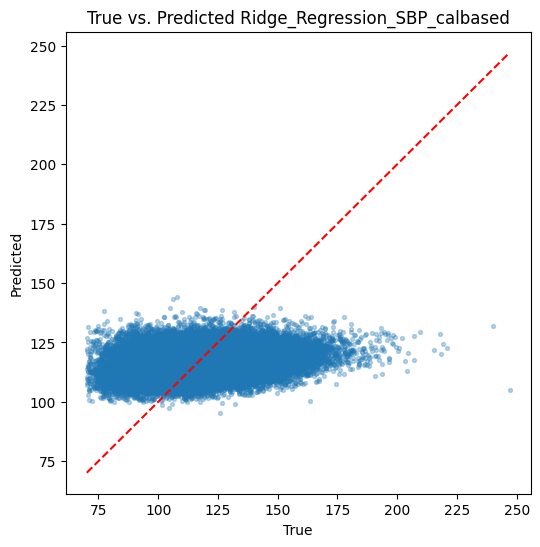

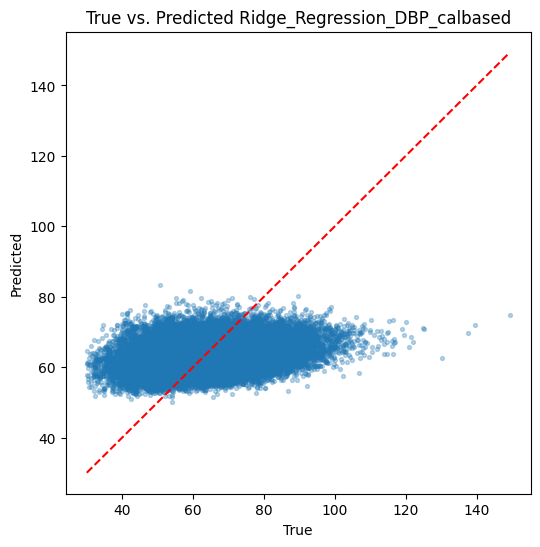

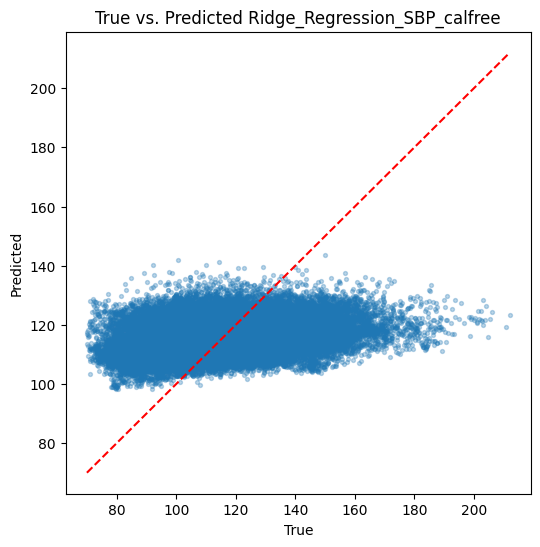

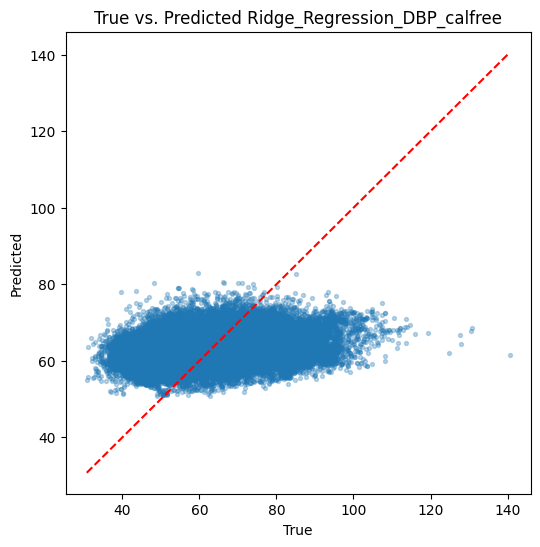

In [5]:
# Linear regression (Ridge) baseline

X_train_lr = make_features(ECG_train, PPG_train)
y_train_lr = df_train[["SBP", "DBP"]].to_numpy(dtype="float32")

X_calbased_lr = make_features(ECG_calbased, PPG_calbased)
y_calbased = df_calbased[["SBP", "DBP"]].to_numpy(dtype="float32")

X_calfree_lr = make_features(ECG_calfree, PPG_calfree)
y_calfree = df_calfree[["SBP", "DBP"]].to_numpy(dtype="float32")

start = time.time()
linear_model = Ridge(alpha=1.0)  # Ridge(alpha=1.0) or LinearRegression()
linear_model.fit(X_train_lr, y_train_lr)
train_time = time.time() - start

y_pred_calbased = linear_model.predict(X_calbased_lr)
y_pred_calfree = linear_model.predict(X_calfree_lr)

linear_metrics = compute_bp_metrics(
    model_name="Linear Regression",
    split_name="calbased",
    y_true=y_calbased,
    y_pred=y_pred_calbased,
    train_time=train_time,
    n_epochs=None,
    metrics_path=metrics_path,
)

linear_metrics_free = compute_bp_metrics(
    model_name="Linear Regression",
    split_name="calfree",
    y_true=y_calfree,
    y_pred=y_pred_calfree,
    train_time=train_time,
    n_epochs=None,
    metrics_path=metrics_path,
)

plot_true_vs_pred(df_calbased["SBP"], y_pred_calbased[:, 0], "Ridge Regression", "calbased", "SBP", fig_dir=FIG_DIR)
plot_true_vs_pred(df_calbased["DBP"], y_pred_calbased[:, 1], "Ridge Regression", "calbased", "DBP", fig_dir=FIG_DIR)
plot_true_vs_pred(df_calfree["SBP"], y_pred_calfree[:, 0], "Ridge Regression", "calfree", "SBP", fig_dir=FIG_DIR)
plot_true_vs_pred(df_calfree["DBP"], y_pred_calfree[:, 1], "Ridge Regression", "calfree", "DBP", fig_dir=FIG_DIR)

del X_train_lr, X_calbased_lr, y_train_lr, y_calbased, y_pred_calbased, X_calfree_lr, y_calfree, y_pred_calfree
gc.collect()

In [8]:
linear_metrics

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,Linear Regression,calbased,SBP,-0.038417,17.919249,14.211845,0.074317,216.62077,None
1,Linear Regression,calbased,DBP,-0.031211,11.278760,8.975644,0.098215,216.62077,None


In [11]:
linear_metrics_free

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,Linear Regression,calfree,SBP,0.321489,17.882399,14.290911,0.078753,216.62077,None
1,Linear Regression,calfree,DBP,0.070565,11.353824,9.029755,0.075383,216.62077,None


In [13]:
train_dataset = PulseDataset(ECG_train, PPG_train, df_train)
val_dataset = PulseDataset(ECG_val, PPG_val, df_val)
test_dataset = PulseDataset(ECG_calbased, PPG_calbased, df_calbased)
test_dataset_free = PulseDataset(ECG_calfree, PPG_calfree, df_calfree)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
test_loader_free = DataLoader(test_dataset_free, batch_size=1024, shuffle=False)

In [15]:
def run_model(model_list, train_loader, val_loader, test_loader, test_loader_free):
    for name, model_class in model_list:
        SBP_pred, DBP_pred, SBP_pred_free, DBP_pred_free, train_time, n_epochs, all_training_loss, all_val_loss = evaluate_model(
            name,
            model_class,
            train_loader,
            val_loader,
            test_loader,
            test_loader_free
        )

        y_true = df_calbased[["SBP", "DBP"]].to_numpy(dtype="float32")
        y_pred = np.column_stack([SBP_pred, DBP_pred])
        y_true_free = df_calfree[["SBP", "DBP"]].to_numpy(dtype="float32")
        y_pred_free = np.column_stack([SBP_pred_free, DBP_pred_free])

        metrics = compute_bp_metrics(
            model_name=name,
            split_name="calbased",
            y_true=y_true,
            y_pred=y_pred,
            train_time=train_time,
            n_epochs=n_epochs,
            metrics_path=metrics_path,
        )

        display(metrics)

        metrics_free = compute_bp_metrics(
            model_name=name,
            split_name="calfree",
            y_true=y_true_free,
            y_pred=y_pred_free,
            train_time=train_time,
            n_epochs=n_epochs,
            metrics_path=metrics_path,
        )

        display(metrics_free)

        plt.figure(figsize=(8, 5))
        plt.plot(all_training_loss, label="Train Loss")
        plt.plot(all_val_loss, label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Training Curve ({name})")
        plt.legend()
        plt.grid(True)
        plt.savefig(FIG_DIR / f"{name}_training_curve.png", dpi=300, bbox_inches="tight")
        plt.show()

        plot_true_vs_pred(df_calbased["SBP"], SBP_pred, name, "calbased", "SBP", fig_dir=FIG_DIR)
        plot_true_vs_pred(df_calbased["DBP"], DBP_pred, name, "calbased", "DBP", fig_dir=FIG_DIR)
        plot_true_vs_pred(df_calfree["SBP"], SBP_pred_free, name, "calfree", "SBP", fig_dir=FIG_DIR)
        plot_true_vs_pred(df_calfree["DBP"], DBP_pred_free, name, "calfree", "DBP", fig_dir=FIG_DIR)

        del SBP_pred, DBP_pred, SBP_pred_free, DBP_pred_free, train_time, n_epochs, all_training_loss, all_val_loss, metrics, metrics_free
        gc.collect()

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,FCNN,calbased,SBP,-1.850729,17.326353,13.642208,0.124690,729.20288,52
1,FCNN,calbased,DBP,-1.386070,11.191632,8.893363,0.098481,729.20288,52


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,FCNN,calfree,SBP,-1.839719,17.771158,14.028372,0.080725,729.20288,52
1,FCNN,calfree,DBP,-1.411915,11.581743,9.217623,0.023628,729.20288,52


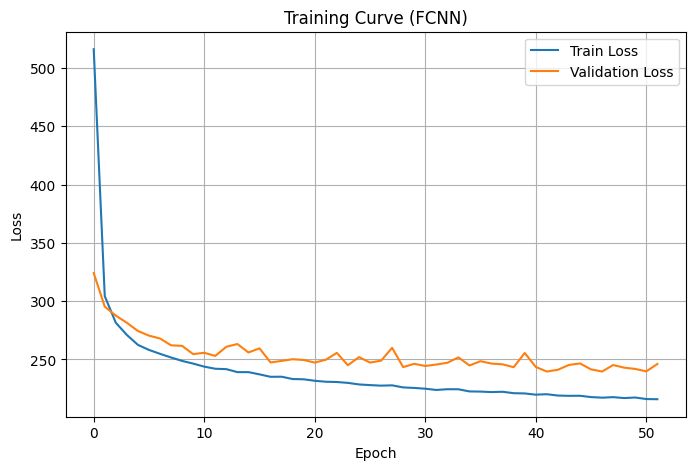

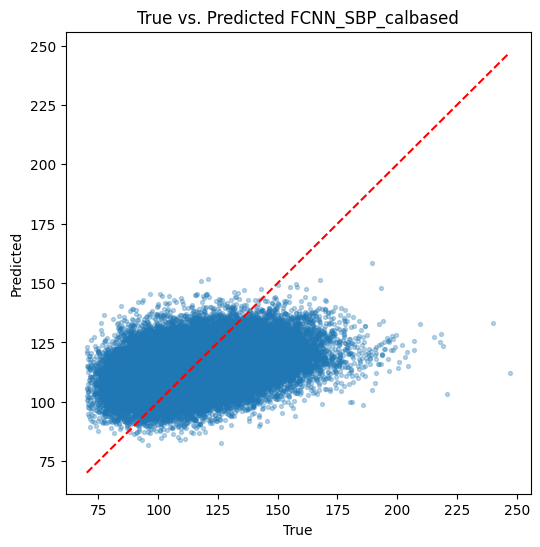

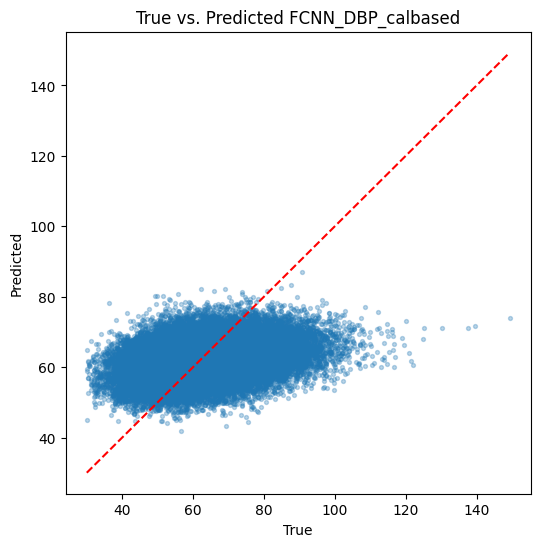

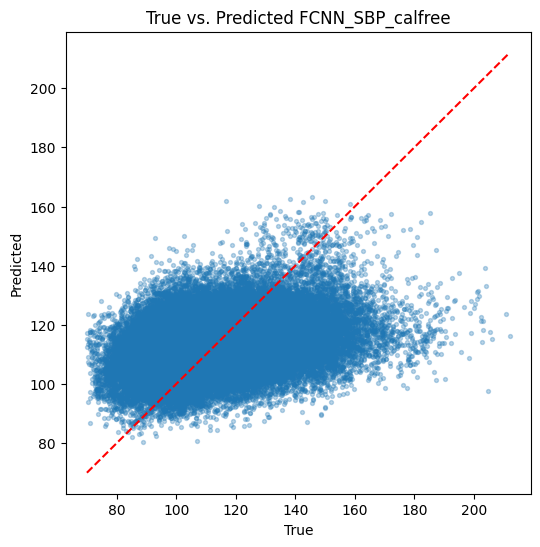

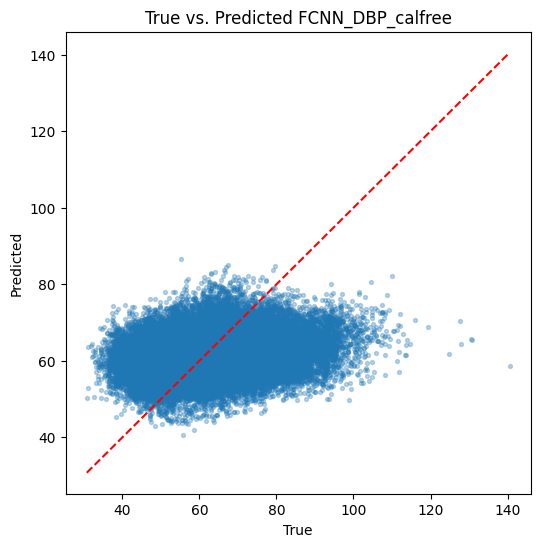

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,1D CNN,calbased,SBP,0.222413,14.833189,11.699911,0.365565,2758.083265,58
1,1D CNN,calbased,DBP,-0.662584,9.732557,7.665911,0.325411,2758.083265,58


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,1D CNN,calfree,SBP,-0.211332,15.924979,12.533054,0.269503,2758.083265,58
1,1D CNN,calfree,DBP,-0.976362,10.228412,8.144800,0.242790,2758.083265,58


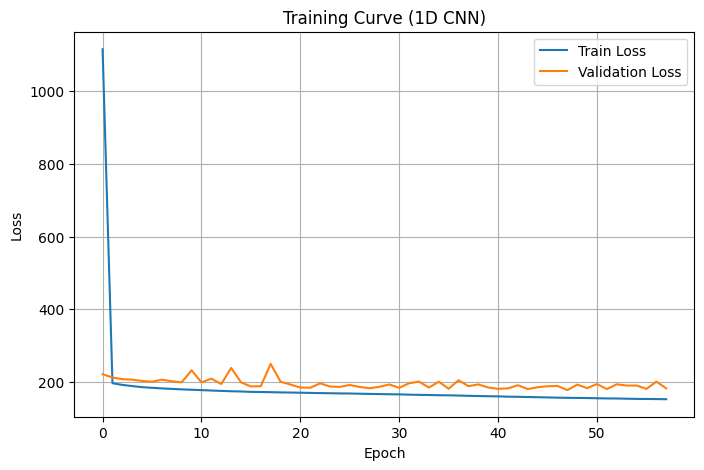

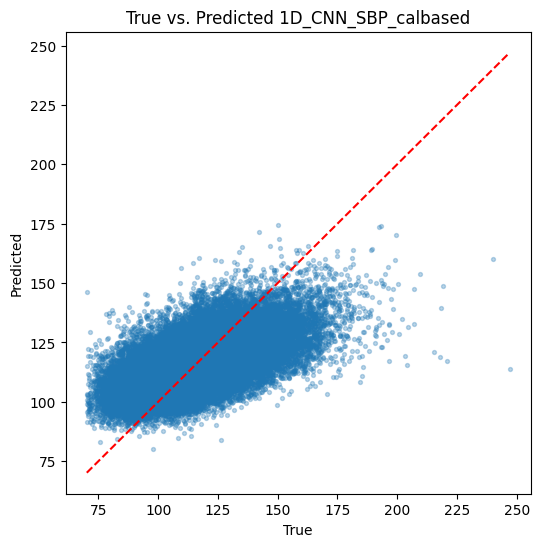

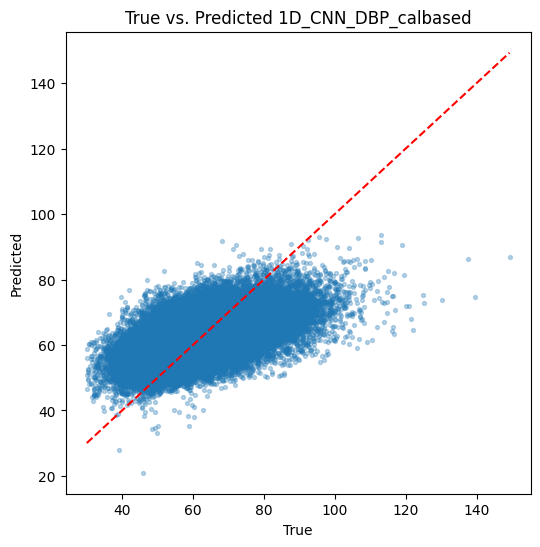

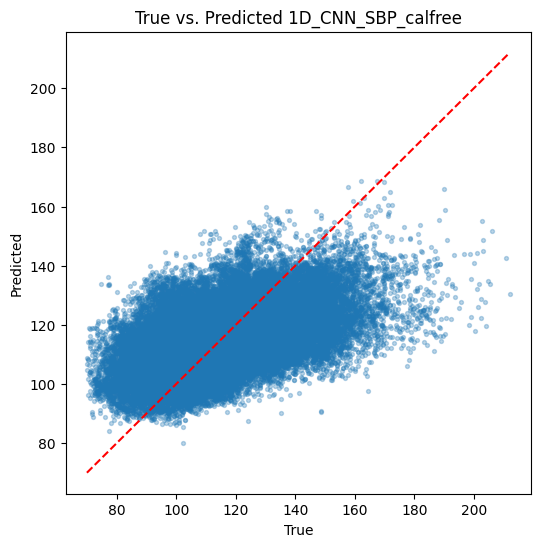

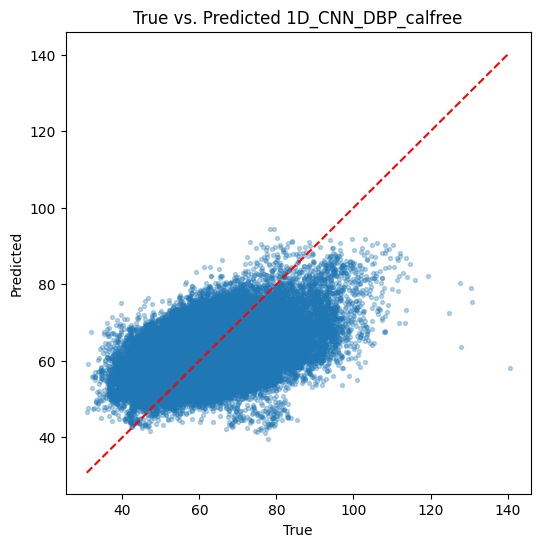

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,GRU,calbased,SBP,-0.382354,14.678414,11.444485,0.378454,4230.972286,91
1,GRU,calbased,DBP,-0.156317,9.913888,7.796640,0.303096,4230.972286,91


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,GRU,calfree,SBP,-1.064462,15.901296,12.448254,0.268539,4230.972286,91
1,GRU,calfree,DBP,-0.582861,10.299218,8.131630,0.236766,4230.972286,91


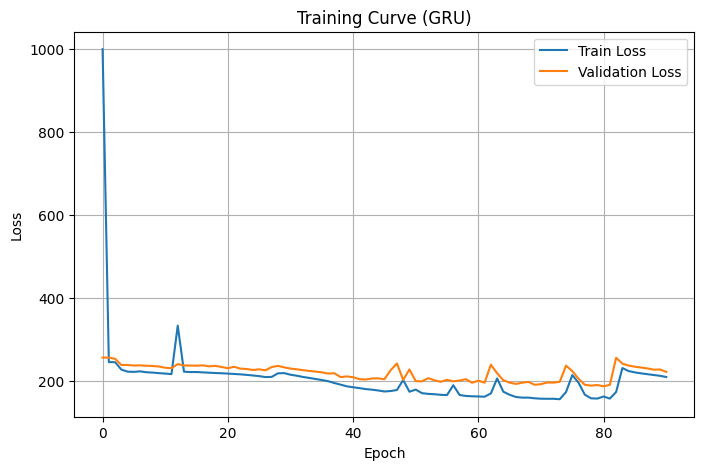

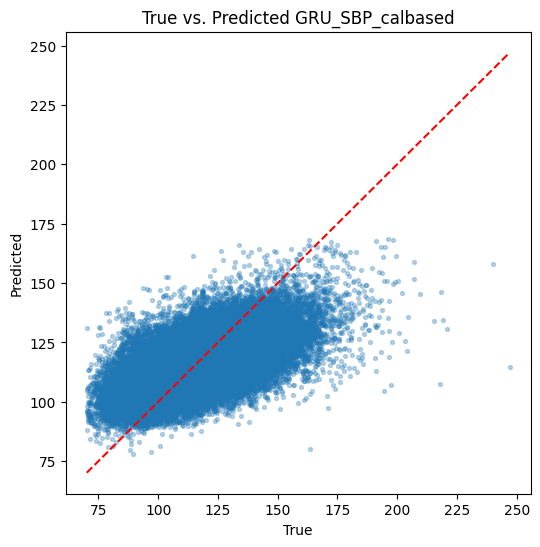

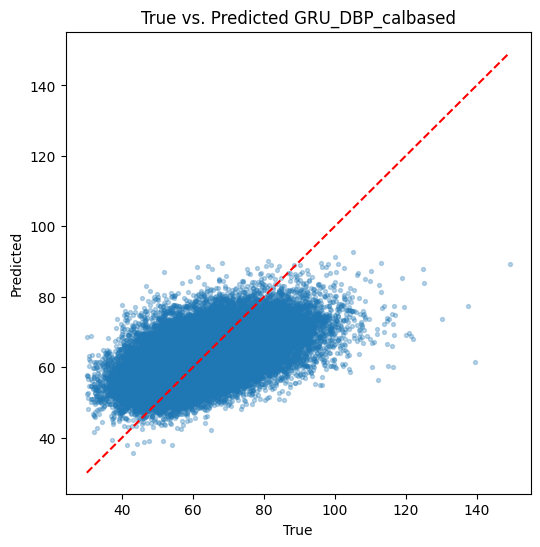

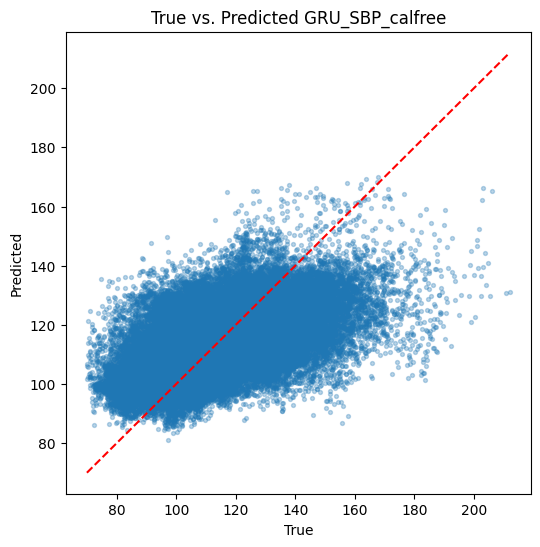

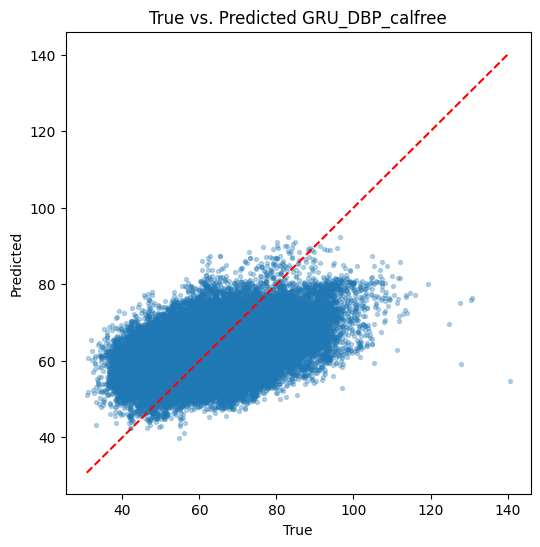

In [17]:
model_list = [
    ("FCNN", FCNN),
    ("1D CNN", CNN1D),
    ("GRU", lambda: RNN(model_type='GRU'))
]

run_model(model_list, train_loader, val_loader, test_loader, test_loader_free)

,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,RNN,calbased,SBP,0.369868,18.587423,14.813027,0.003607,781.015997,33
1,RNN,calbased,DBP,0.332943,11.820441,9.417276,0.008737,781.015997,33


,Model,Split,Variable,ME,SDE,MAE,R2,Time,Number of epochs
0,RNN,calfree,SBP,0.638357,18.567989,14.871362,0.005907,781.015997,33
1,RNN,calfree,DBP,0.373248,11.745413,9.355662,0.009543,781.015997,33


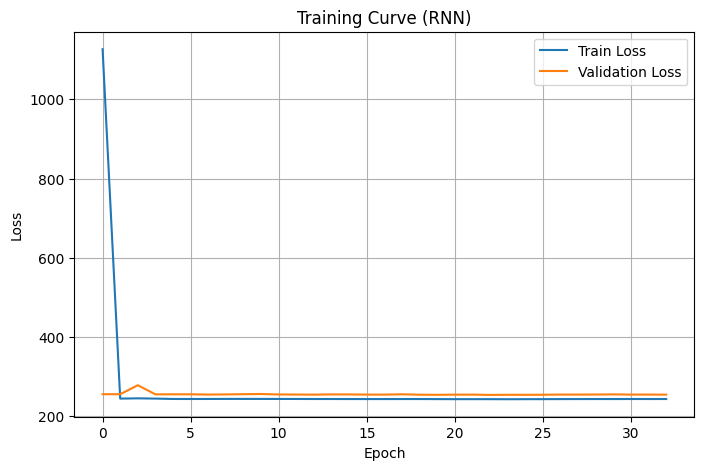

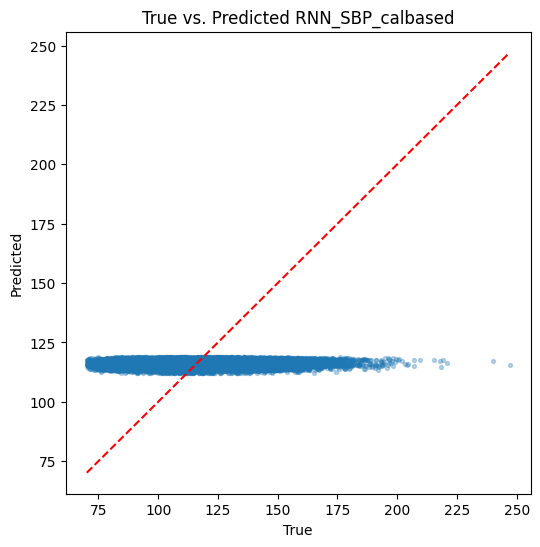

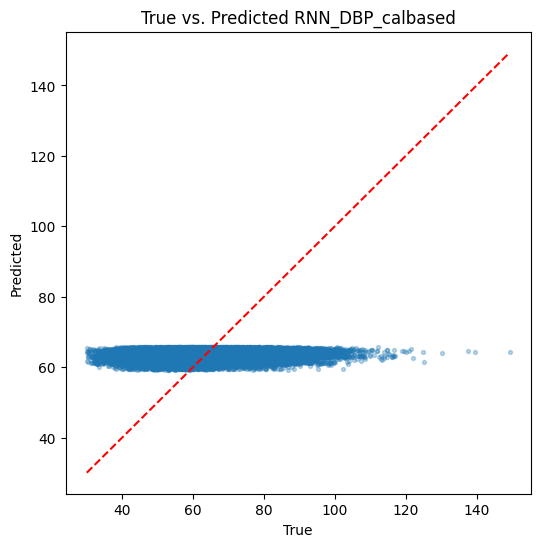

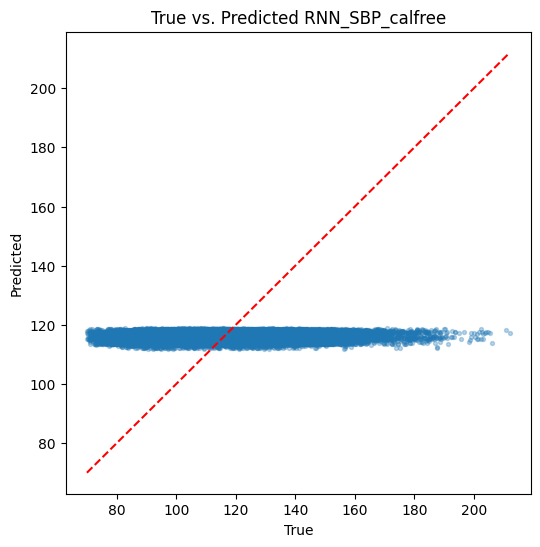

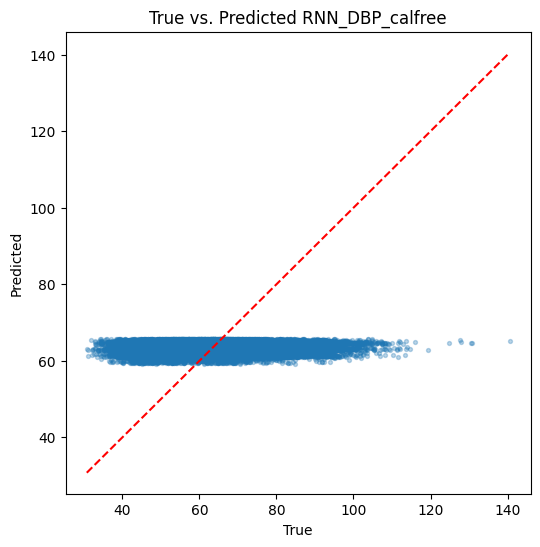

In [ ]:
model_list = [
    ("RNN", lambda: RNN(model_type='RNN')),
    ("LSTM", lambda: RNN(model_type='LSTM')),
]

run_model(model_list, train_loader, val_loader, test_loader, test_loader_free)

In [ ]:
model_list = [
    ("Transformer", Transformer)
]

run_model(model_list, train_loader, val_loader, test_loader, test_loader_free)